# Wykład 6: Wstępne przetwarzanie danych

W ramach tego wykładu poruszone zostaną zagadnienia:
* skalowania i normalizacji wartości cech,
* selekcji cech,
* redukcji wymiarowości.

## 1. Skalowanie i normalizacja wartości cech

### Dlaczego musimy skalować dane?

  * Modele oparte na odległości (np. k-NN, K-Means, SVM) są bardzo wrażliwe na różnice w rzędach wielkości (np. wiek [0-100] vs dochód [1000-100000]).
  * Algorytmy oparte na spadku gradientu (np. sieci neuronowe, regresja logistyczna) zbiegają szybciej po przeskalowaniu.

**1. Standaryzacja (Z-score normalization / StandardScaler):**

  * **Wzór:**
    $$ \huge z = \frac{x - \mu}{\sigma}$$
    gdzie  
    $\mu$ to średnia, a $\sigma$ to odchylenie standardowe
  * Sprowadzanie danych do średniej = 0 i odchylenia standardowego = 1.
  * **Kiedy stosować:**  
    Regresja liniowa, regresja logistyczna, sieci neuronowe, SVM.

    **Ważna uwaga:**    
    Standaryzacja nie zmienia kształtu oryginalnego rozkładu (nie robi z niego rozkładu normalnego, jeśli wcześniej nim nie był). Po prostu przesuwa i ściska/rozciąga dane na osi.
    
**2. Normalizacja Min-Max (MinMaxScaler):**
  * **Wzór:**
    $$ \huge x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$
  * Przekształcenie zakresu na `[0, 1]` (lub `[-1, 1]`).
  * **Kiedy stosować:**  
    Kiedy algorytm oczekuje danych w konkretnym przedziale (np. niektóre funkcje aktywacji w sieciach neuronowych) lub gdy znamy fizyczne granice danych (np. piksele obrazu zawsze mają wartości od 0 do 255).

  * **Wada:**  
    Jest ekstremalnie wrażliwe na wartości odstające (outliery). Jeden gigantyczny błąd w danych sprawi, że wszystkie poprawne wartości zostaną ściśnięte w okolicach zera.

**3. RobustScaler:**  
    Gdy dane są zanieczyszczone ekstremalnymi wartościami, użycie średniej i wariancji (jak w standaryzacji) lub minimów i maksimów (jak w Min-Max) zafałszuje cały proces.
    W takich sytuacjach należy omówić **metody oparte na statystykach odpornych**, np. właśnie RobustScaler. Używa on mediany i rozstępu międzykwartylowego (IQR) zamiast średniej i odchylenia standardowego.
    * **Wzór:**
    $$ \huge x_{robust} = \frac{x - Q_2}{Q_3 - Q_1}$$
    gdzie  
    $Q_2$ to mediana, a $Q_3 - Q_1$ to rozstęp ćwiartkowy IQR).
    
**4. MaxAbsScaler:** Często stosowany dla danych rzadkich (ang. *sparse data*).
    * **Wzór:**
    $$ \huge x_{maxabs} = \frac{x}{|x_{max}|}$$

**Unikanie wycieku danych (Data Leakage) przy operacji skalowania danych**

To najczęstszy i najbardziej krytyczny błąd początkujących. Skalowanie musi być obliczane (parametry $\mu$, $\sigma$, minima, maksima) wyłącznie na zbiorze treningowym. 

Proces wygląda następująco:
* Podziel dane na zbiór treningowy i testowy.
* Dopasuj skaler (np. wylicz średnią) tylko na danych treningowych.
* Przetransformuj dane treningowe za pomocą tego skalera.
* Przetransformuj dane testowe za pomocą tych samych, "zamrożonych" parametrów ze zbioru treningowego.

Jeśli zrobisz to przed podziałem danych, informacje o wartościach maksymalnych czy średnich ze zbioru testowego wpłyną na zbiór treningowy, co stworzy sztucznie zawyżone wyniki ewaluacji.

### Podsumowanie

Warto również podsumować, które narzędzia faktycznie potrzebują skalowania.

| Typ algorytmu | Przykłady | Czy wymaga skalowania? |
| :--- | :--- | :--- |
| **Oparte na dystansie** | k-NN, K-Means, SVM, PCA | Bezwzględnie tak |
| **Oparte na gradiencie** | Regresja Liniowa/Logistyczna, Sieci Neuronowe | Bardzo mocno zalecane |
| **Oparte na drzewach** | Random Forest, XGBoost, LightGBM | Nie (są na to całkowicie odporne) |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

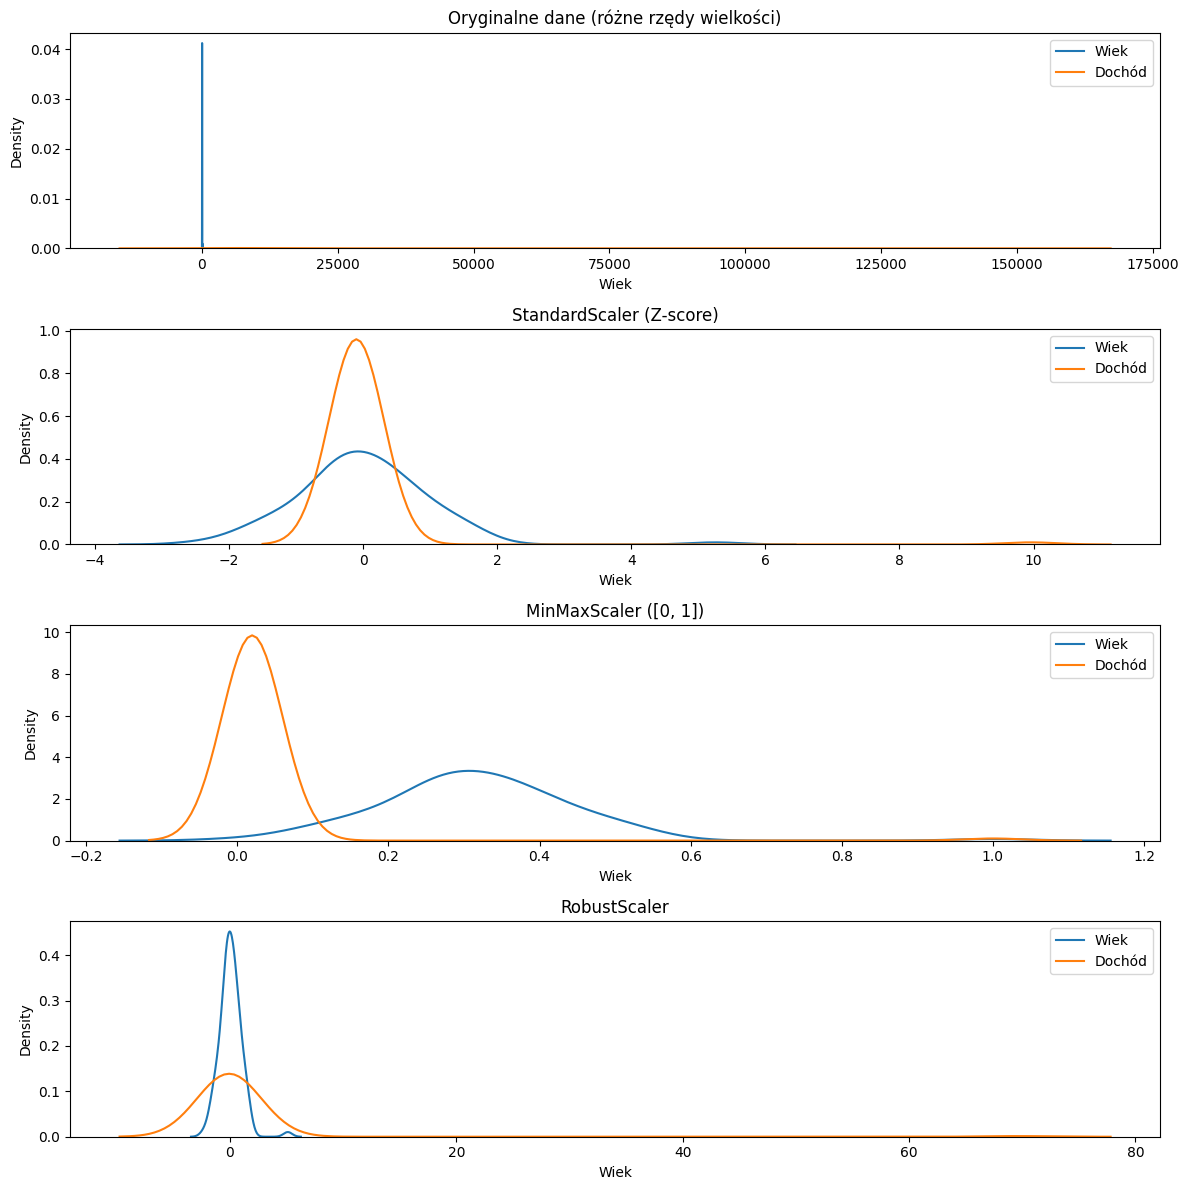

In [11]:
# 1. Wygenerowanie przykładowych danych (np. Wiek i Dochód z outlierem)
np.random.seed(42)
wiek = np.random.normal(40, 10, 100)
dochod = np.random.normal(5000, 1500, 100)

# Dodanie wartości odstającej (outliera)
wiek = np.append(wiek, 95)
dochod = np.append(dochod, 150000)

df = pd.DataFrame({'Wiek': wiek, 'Dochód': dochod})

# 2. Skalowanie danych
scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()
scaler_robust = RobustScaler()

df_std = pd.DataFrame(scaler_std.fit_transform(df), columns=df.columns)
df_minmax = pd.DataFrame(scaler_minmax.fit_transform(df), columns=df.columns)
df_robust = pd.DataFrame(scaler_robust.fit_transform(df), columns=df.columns)

# 3. Wizualizacja (KDE Plot)
fig, axes = plt.subplots(4, 1, figsize=(12, 12))

# Rozkłady oryginalne
sns.kdeplot(data=df, x='Wiek', ax=axes[0], label='Wiek')
sns.kdeplot(data=df, x='Dochód', ax=axes[0], label='Dochód')
axes[0].set_title("Oryginalne dane (różne rzędy wielkości)")
axes[0].legend()

# Rozkłady ustandaryzowane
sns.kdeplot(data=df_std, x='Wiek', ax=axes[1], label='Wiek')
sns.kdeplot(data=df_std, x='Dochód', ax=axes[1], label='Dochód')
axes[1].set_title("StandardScaler (Z-score)")
axes[1].legend()

# Rozkłady znormalizowane (Min-Max)
sns.kdeplot(data=df_minmax, x='Wiek', ax=axes[2], label='Wiek')
sns.kdeplot(data=df_minmax, x='Dochód', ax=axes[2], label='Dochód')
axes[2].set_title("MinMaxScaler ([0, 1])")
axes[2].legend()

# Rozkłady skalowane poprzez Robust scaler
sns.kdeplot(data=df_robust, x='Wiek', ax=axes[3], label='Wiek')
sns.kdeplot(data=df_robust, x='Dochód', ax=axes[3], label='Dochód')
axes[3].set_title("RobustScaler")
axes[3].legend()

plt.tight_layout()
plt.show()

**Wnioski z analizy wykresów:**
* **Brak skalowania:**  
  Na oryginalnym wykresie krzywa `Wieku` jest zupełnie niewidoczna ("spłaszczona"), ponieważ `Dochód` dominuje skalę osi X (dziesiątki tysięcy). Taka sama dominacja zajdzie w modelu ML w trakcie obliczania odległości (np. w k-NN).
* **StandardScaler:**  
  Przesuwa średnią w rejon zera a odchylenie standardowe do 1 dla obu cech. Skrajna wartość odstająca (150 000 zł) zyskuje wartość Z-score powyżej kilkudziesięciu. Modele stają się stabilniejsze.
  
* **MinMaxScaler:**  
  Ściśle kompresuje wszystkie wartości do przedziału `[0, 1]`. Poprzez obecność pojedynczego ouliera, cała docelowa grupa dochodu ("zwykli obywatele") zostaje wepchnięta i zgnieciona bardzo blisko wartości zero. To idealny przykład do wyjaśnienia, dlaczego Min-Max może sprawiać kłopoty, gdy nie usuniemy wcześniej wartości odstających.

* **RobustScaler:**  
  Widać pewną zbieżność z wynikami skalowania standardowego, ale widać jednocześnie znacznie większe ściśnięcie wartości dla obu cech. 

### 1.1 Praktyczny przykład wpływu skalowania cech na jakość modelu ML

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# Wygenerowanie prostego zbioru klasyfikacyjnego
# Wyobraźmy sobie prosty problem: próbujemy przewidzieć decyzję (0, 1) głównie na podstawie wieku.
np.random.seed(42)
wiek = np.random.uniform(20, 60, 200)
dochod = np.random.uniform(3000, 10000, 200) # Znacząco większe wartości
# Sztuczna reguła: jeśli waga wieku przekracza próg 40 - np. diagnoza pewnej przypadłości mocno skorelowanej z wiekiem.
target = (wiek > 40).astype(int)

X = pd.DataFrame({'Wiek': wiek, 'Dochod': dochod})
y = target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Trening modelu bazowego bez uprzedniego skalowania
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test)

# Skalowanie w potoku (Pipeline), ułatwia wykluczanie data leakage z danych testowych

knn_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])
knn_scaled.fit(X_train, y_train)
y_pred_scaled = knn_scaled.predict(X_test)

# to jeszcze dorzucimy skalowanie metodą min-max
knn_minmax_scaled = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])
knn_minmax_scaled.fit(X_train, y_train)
y_pred_minmax_scaled = knn_minmax_scaled.predict(X_test)

# to jeszcze dorzucimy skalowanie metodą robust
knn_robust_scaled = Pipeline([
    ('scaler', RobustScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])
knn_robust_scaled.fit(X_train, y_train)
y_pred_robust_scaled = knn_robust_scaled.predict(X_test)


print(f"Dokładność k-NN bez skalowania: {accuracy_score(y_test, y_pred_unscaled):.2f}")
print(f"Dokładność k-NN ze skalowaniem standardowym: {accuracy_score(y_test, y_pred_scaled):.2f}")
print(f"Dokładność k-NN ze skalowaniem min-max: {accuracy_score(y_test, y_pred_minmax_scaled):.2f}")
print(f"Dokładność k-NN ze skalowaniem metodą robust: {accuracy_score(y_test, y_pred_robust_scaled):.2f}")

Dokładność k-NN bez skalowania: 0.48
Dokładność k-NN ze skalowaniem standardowym: 0.97
Dokładność k-NN ze skalowaniem min-max: 0.97
Dokładność k-NN ze skalowaniem metodą robust: 0.97


**Wnioski po uruchomieniu powyższego kodu:**
* Wynik rzędu ~0.50 przed skalowaniem vs ~0.95 po skalowaniu.
* Ponieważ k-NN szuka "najbliższych sąsiadów" na podstawie wektorów, oś dochodów ($3000$-$10000$) generuje potężne odległości euklidesowe, przy których wiek ($20$-$60$) staje się pomijalnie małym przyrostem ("statystycznym błędem zaokrąglenia"). Skutkiem tego model de facto ignoruje wiek pomimo, że zdefiniowaliśmy go jako filar docelowej etykiety.
* Dopiero po nałożeniu `StandardScaler`, obie zmienne mają podobny wpływ geometryczny. Skalowanie zmusza model do zauważenia mniejszych — i często znacznie ważniejszych — cech w badanym zbiorze.

## 2. Selekcja cech

Na wykładzie numer 3, w trakcie którego omawiany był temat korelacji danych, jako jedną z "mądrości", którą możemy wyciągnąć z analizy korelacji jest istotność cech. 

Dla przypomnienia:
* **wysoka korelacja pomiędzy predyktorami** może nam zasugerować **zbiór cech, które możemy pominąć** w wyborze dla docelowego zbioru treningowego - są informacją nadmiarową,
* **wysoka korelacja pomiędzy predyktorem a celem** może sugerować **cechy, które powinny pozostać w zbiorze**, gdyż dobrze opisują coś co próbujemy przewidywać.

Korelacja nie jest jednak jedynym sposobem jaki mamy do dyspozycji.

* **Czym jest selekcja cech i dlaczego ją robimy?**
  * Zmniejszenie ryzyka przeuczenia (Overfitting), przyspieszenie trenowania algorytmów, lepsza interpretowalność za cenę odrzucenia części informacji.
  * Odrzucanie zmiennych skorelowanych (redundantnych) i niosących mało informacji.

* **Metody filtrowania (Filter Methods):**
  * Niezależne od algorytmu docelowego, szybkie.
  * Użycie korelacji (Pearson, Spearman).
  * Testy statystyczne (np. $\chi^2$ dla zmiennych kategorycznych, ANOVA).
  * Odcięcie zmiennych o niskiej wariancji (`VarianceThreshold`). Cecha przypominająca stałą (ta sama niemal wartość dla każdego rzędu) nie wnosi zróżnicowania informacyjnego i spowalnia model.
* **Metody opakowujące (Wrapper Methods):**
  * Oceniają podzbiory cech za pomocą wybranego modelu uczenia maszynowego.
  * Przykłady: RFE (Recursive Feature Elimination), Forward/Backward Selection.
  * Wady: bardzo zasobochłonne obliczeniowo.
* **Metody wbudowane (Embedded Methods):**
  * Selekcja jest częścią procesu trenowania algorytmu (kompromis między filter a wrapper).
  * Regularyzacja L1 (Lasso) - naturalnie zeruje wagi dla nieistotnych zmiennych.
  * Ważność cech z modeli opartych na drzewach (np. Random Forest Feature Importance).

### 2.1 Przykłady metod filtrowania jako metod selekcji cech

**Filtrowanie cech na podstawie progu wariancji (`VarianceThreshold`)**

Bardzo prosta, ale wysoce użyteczna metoda. Stosuje się ją na samym początku filtrowania potoku, aby odciąć "puste przebiegi", czyli kolumny wejściowe będące cechami stałymi lub niemal stałymi.

In [2]:
from sklearn.feature_selection import VarianceThreshold

# Wygenerowanie małego zestawu danych demonstracyjnych
# F1: cecha o dużej zmienności
# F2: cecha niemal stała (bardzo powtarzalne wejścia)
# F3: cecha w pełni stała (np. sztuczna flaga przypisana z migracji bazy danych)
data = {
    'F1': [10, 20, 15, 30, 25, 40],
    'F2': [0, 0, 0, 1, 0, 0],
    'F3': [5, 5, 5, 5, 5, 5]
}
df = pd.DataFrame(data)

print("Oryginalny zbiór:")
print(df)

# Ustawienie progu (threshold). Zostaną tylko kolumny z wariancją > próg.
# Domyślnie threshold=0 usunąłby tylko kolumnę F3.
# Zwiększamy nieznacznie próg na 0.15, co wytnie również wyjątkowo jednorodną F2.
selector = VarianceThreshold(threshold=0.15)
df_filtered_array = selector.fit_transform(df)

# Wyłuskiwanie przetrwałych kolumn z obiektu estymatora, by połączyć to z nazwami z ramki pandas
przetrwale_kolumny = df.columns[selector.get_support()]
df_filtered = pd.DataFrame(df_filtered_array, columns=przetrwale_kolumny)

print("\n------------------------------")
print("Zbiór po akcji VarianceThreshold (próg=0.15):")
print(df_filtered)

Oryginalny zbiór:
   F1  F2  F3
0  10   0   5
1  20   0   5
2  15   0   5
3  30   1   5
4  25   0   5
5  40   0   5

------------------------------
Zbiór po akcji VarianceThreshold (próg=0.15):
   F1
0  10
1  20
2  15
3  30
4  25
5  40


**Wnioski:**

Widzimy, że model odrzucił podrzędne i słabo wykwalifikowane wektory F2 i F3. 

Cechą tej metody jest fakt odcięcia filtrującego wyłącznie opartego na wejściach (`X`). 

Nie sprawdzamy tutaj korelacji z celem (`y`), a pozbywamy się tzw. śmieci matematycznych generujących koszty obliczeniowe podczas działania potoku.

**Praktyczny przykład na rzeczywistym zbiorze (`Wine Quality`) i pułapka skali**

Poniższy skrypt pokazuje użycie analizy wariancji na rzeczywistym, popularnym zbiorze `load_wine` z biblioteki `sklearn`. Prezentuje też **najczęstszy błąd poczatkujących**, czyli użycie bezwzględnego progu wariancji na danych celowo nieprzeskalowanych.

In [4]:
from sklearn.datasets import load_wine

# 1. Załadowanie zbioru
data = load_wine()
df_wine = pd.DataFrame(data.data, columns=data.feature_names)

print("Wariancja dla poszczególnych cech w zbiorze Wine (Top/Bottom):")
# Posortowana, rozproszona wariancja w przestrzeni pandas
wariancje = df_wine.var().sort_values(ascending=False)
print("Najwyższa:")
print(wariancje.head(5))
print("Najniższa:")
print(wariancje.tail(5))

# 2. Selekcja progiem. Ustawmy próg na np. 0.1
# Odetnie to np. "nonflavanoid_phenols" (wariancja ~0.015) 
# czy "hue" (wariancja ~0.05)
prog = 0.1
selector_wine = VarianceThreshold(threshold=prog)
wine_filtered = selector_wine.fit_transform(df_wine)

# Zbieramy nazwy
zostawione = df_wine.columns[selector_wine.get_support()]
odrzucone = [kol for kol in df_wine.columns if kol not in zostawione]

print("\n------------------------------")
print(f"Odrzucono cechy o wariancji < {prog}: \n{odrzucone}")
print(f"Pozostało: {len(zostawione)} cech z {len(df_wine.columns)} wejściowych.")

Wariancja dla poszczególnych cech w zbiorze Wine (Top/Bottom):
Najwyższa:
proline              99166.717355
magnesium              203.989335
alcalinity_of_ash       11.152686
color_intensity          5.374449
malic_acid               1.248015
dtype: float64
Najniższa:
total_phenols           0.391690
proanthocyanins         0.327595
ash                     0.075265
hue                     0.052245
nonflavanoid_phenols    0.015489
dtype: float64

------------------------------
Odrzucono cechy o wariancji < 0.1: 
['ash', 'nonflavanoid_phenols', 'hue']
Pozostało: 10 cech z 13 wejściowych.


**Kluczowa uwaga po uruchomieniu skryptu:**

Wariancja to jednostka w kwadracie. Dla kolumny "proline" (ilość aminokwasu, liczby > 500) wariancja to ponad $99000$. Dla kolumny "nonflavanoid_phenols" (małe ułamki), wariancja wynosi $0.015$. 
Użycie `VarianceThreshold` w powyższy sposób niesie ogromne niebezpieczeństwo - odrzuciliśmy `nonflavanoid_phenols` tylko dlatego, że zostało zapisane w małych ułamkach, a nie dlatego, że niesie mało informacji!
Dlatego analiza wariancji **zawsze musi zakładać przemyślane skale** lub być poprzedzona użyciem np. `MinMaxScaler()` (który zamyka dane w `[0,1]` zachowując względną proporcję punktów, dzięki czemu niskie wariancje na tych ułamkach będą oznaczać faktycznie wskaźniki niemal stałe).

In [19]:
# 1. Załadowanie zbioru
data = load_wine()
df_wine = pd.DataFrame(data.data, columns=data.feature_names)

# najpierw dokonamy przeskalowania danych
wine_scaled = Pipeline([
    ('scaler', MinMaxScaler())
])

wine_scaled_np = wine_scaled.fit_transform(df_wine)
wine_scaled_df = pd.DataFrame(wine_scaled_np, columns=df_wine.columns)

print("Wariancja dla poszczególnych cech w zbiorze Wine (Top/Bottom):")
# Posortowana, rozproszona wariancja w przestrzeni pandas
wariancje = wine_scaled_df.var().sort_values(ascending=False)
print("Najwyższa:")
print(wariancje.head(5))
print("Najniższa:")
print(wariancje.tail(5))

# 2. Selekcja progiem. Ustawmy próg na np. 0.1
prog = 0.1
selector_wine = VarianceThreshold(threshold=prog)
wine_filtered = selector_wine.fit_transform(wine_scaled_df)

# Zbieramy nazwy
zostawione = wine_scaled_df.columns[selector_wine.get_support()]
odrzucone = [kol for kol in wine_scaled_df.columns if kol not in zostawione]

print("\n------------------------------")
print(f"Odrzucono cechy o wariancji < {prog}: \n{odrzucone}")
print(f"Pozostało: {len(zostawione)} cech z {len(wine_scaled_df.columns)} wejściowych.")

Wariancja dla poszczególnych cech w zbiorze Wine (Top/Bottom):
Najwyższa:
od280/od315_of_diluted_wines    0.067636
nonflavanoid_phenols            0.055139
proline                         0.050451
malic_acid                      0.048744
total_phenols                   0.046574
dtype: float64
Najniższa:
hue                  0.034533
proanthocyanins      0.032600
alcalinity_of_ash    0.029633
magnesium            0.024101
ash                  0.021523
dtype: float64


ValueError: No feature in X meets the variance threshold 0.10000

**Wnioski**

Tym razem po przeskalowaniu żadna cecha nie spełnia warunku **pozostania** w zbiorze finalnym!

Możemy do tego podejść określając próg jako wartość największą z np. **n** ostatnich wartości wariancji lub wykonując bardziej miarodajną analizę rozkładu wariancji. Może się okazać, że rozkład zasugeruje iż nie jest dobrym pomysłem usuwanie żadnej cechy przy tym typie skalowania (lub żadnym innym).

Częstą praktyką jest odrzucanie cech, dopóki te pozostające wyjaśniają co najmniej ustalony próg całego zbioru (np. 95%). Możemy to zastosować tutaj.

In [20]:
# tak z ciekawości - w skleran właśnie tak wizualizowane jest wiele jego komponentów
selector_wine

,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.1


In [22]:
wariancje

od280/od315_of_diluted_wines    0.067636
nonflavanoid_phenols            0.055139
proline                         0.050451
malic_acid                      0.048744
total_phenols                   0.046574
alcohol                         0.045641
flavanoids                      0.044407
color_intensity                 0.039127
hue                             0.034533
proanthocyanins                 0.032600
alcalinity_of_ash               0.029633
magnesium                       0.024101
ash                             0.021523
dtype: float64

In [23]:
# % - procentowo
wariancje / sum(wariancje)

od280/od315_of_diluted_wines    0.125227
nonflavanoid_phenols            0.102089
proline                         0.093409
malic_acid                      0.090248
total_phenols                   0.086231
alcohol                         0.084504
flavanoids                      0.082218
color_intensity                 0.072443
hue                             0.063937
proanthocyanins                 0.060358
alcalinity_of_ash               0.054865
magnesium                       0.044622
ash                             0.039850
dtype: float64

In [25]:
# dzięki sumie skumulowanej będzie to proste
cum_var = np.cumsum(wariancje / sum(wariancje))
cum_var

od280/od315_of_diluted_wines    0.125227
nonflavanoid_phenols            0.227316
proline                         0.320724
malic_acid                      0.410972
total_phenols                   0.497203
alcohol                         0.581707
flavanoids                      0.663925
color_intensity                 0.736368
hue                             0.800305
proanthocyanins                 0.860663
alcalinity_of_ash               0.915528
magnesium                       0.960150
ash                             1.000000
dtype: float64

In [39]:
# mamy True lub False ( dziesiętnie 1 lub 0) i szukamy pozycji z maksymalną wartością argumentu
# a jak są równoważme to zwraca pierwszy indeks - tu pierwszą wartość > 95, pozostaje wybrać tylko cechy
threshold = 0.95
cum_var[:np.argmax(cum_var > threshold) + 1].index

Index(['od280/od315_of_diluted_wines', 'nonflavanoid_phenols', 'proline',
       'malic_acid', 'total_phenols', 'alcohol', 'flavanoids',
       'color_intensity', 'hue', 'proanthocyanins', 'alcalinity_of_ash',
       'magnesium'],
      dtype='str')

**Podsumowanie**

Poniżej tabela prezentująca również kilka innych metod z tej rodziny i wskazówki kiedy sprawdzają się najlepiej.


| Metoda | Typ zmiennej docelowej | Typ cechy | Wychwytuje zależności nieliniowe | Niezależna od modelu |
| :--- | :--- | :--- | :--- | :--- |
| **Próg wariancji** | Dowolna | Dowolna | Nie | Tak |
| **Korelacja** | Ciągła | Ciągła | Nie | Tak |
| **Chi-kwadrat** | Kategoryczna | Kategoryczna | Nie | Tak |
| **Informacja wzajemna** | Dowolna | Dowolna | Tak | Tak |
| **Test F ANOVA** | Kategoryczna | Ciągła | Nie | Tak |

_źródło: https://www.geeksforgeeks.org/_

### 2.2 Przykładowa selekcja metodą opakowującą (wrapper)

Metody "Wrapper" wielokrotnie testują wydajność rożnych podzbiorów cech z użyciem konkretnego modelu. Dobrym przykładem jest iteracyjna klasa `SequentialFeatureSelector`. Algorytm startuje od zbioru pustego (0 cech) i w każdym kroku pętli sprawdza wszystkie możliwe do dodania pojedyncze cechy – finalnie dokładając na stałe tę, która gwarantuje największy skok dokładności wybranego estymatora (np. drzewa decyzyjnego), aż do osiągnięcia zadanego limitu wymiarów.

In [41]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SequentialFeatureSelector

# 1. Załadowanie zbioru (rozpoznawanie nowotworu) - 30 oryginalnych cech wejściowych
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# 2. Inicjalizacja modelu bazowego (Czarnej skrzynki diagnozującej poprawność)
# Forward Selection MUSI działać w oparciu o konkretny "testera" (estymator)
drzewo = DecisionTreeClassifier(random_state=42)

# 3. Konfiguracja Sequential Feature Selector (wersja Forward)
# Ustawiamy direction='forward'
sfs = SequentialFeatureSelector(
    estimator=drzewo, 
    # n_features_to_select=3, 
    direction='forward',
    cv=3,       # Weryfikacja dokładności za pomocą 3-krotnej walidacji krzyżowej (CrossVal)
    n_jobs=-1   # Przyspieszenie przez obliczenia równoległe na wielu rdzeniach CPU
)

print("Trwa iteracyjne budowanie siatki i selekcja cech (proces ten jest zasobożerny!)...")
sfs.fit(X, y)

# 4. Sprawdzenie wyniku - macierz powiązań wektorów True/False
wybrane_cechy_sfs = X.columns[sfs.get_support()]

print("-" * 50)
print(f"Wytypowane optymalne cechy (rozpoczynano z {X.shape[1]}):")
for idx, f in enumerate(wybrane_cechy_sfs):
    print(f"{idx+1}. {f}")

Trwa iteracyjne budowanie siatki i selekcja cech (proces ten jest zasobożerny!)...
--------------------------------------------------
Wytypowane optymalne 3 cechy (rozpoczynano z 30):
1. mean perimeter
2. mean compactness
3. mean concavity
4. mean concave points
5. mean symmetry
6. mean fractal dimension
7. area error
8. compactness error
9. concave points error
10. fractal dimension error
11. worst texture
12. worst concavity
13. worst concave points
14. worst symmetry
15. worst fractal dimension


**Wnioski omawiające algorytm:**

Zastosowany wyżej algorytm `SequentialFeatureSelector` jest "zewnętrzną" pętlą ewaluacyjną. Drzewo klasyfikacyjne w tym procesie działa wyłącznie jako tester. Pętla podkłada mu jedną cechę, zgłasza wynik, podkłada drugą, zgłasza wynik, a potem zespala najsilniejsze wygrane. Robi to na solidnie zwalidowanym potoku z CrossVal (walidacji krzyżowej).

Ukazuje to potężną różnicę filozofii względem metod filtrujących. Prosty test `VarianceThreshold` przechodzi po gigantycznym wektorze macierzy $X$ w kilka milisekund nie wiedząc nic o tym, co chcemy nim osiągnąć. W przeciwieństwie do tego, metoda opakowująca uczy się setki razy małych prototypów modelu opartych o Target $y$. Taka potęga kosztuje - "brute-force" pętli Forward przy bazach liczących tysiące wymiarów potrafi zablokować serwer na stałe bez redukcji wymiarów z użyciem chociażby PCA przed startem eksperymentu. Dlatego filtry wstępne to konieczność.

Pozostałe metody z tej rodziny są bardzo podobne w działaniu. Metody wstecznej eliminacji rozpoczynają od pełnego zbioru cech i w kolejnych iteracjcha usuwają kolejce cechy sprawdzając jak w tym kroku radzi sobie estymator. Jest to metoda, którą można zakwalifikować to metod "walca drogowego", którą lubi przytaczać chociażby Profesor Andrzej Dragan, czyli takie, które nie charakteryzują się raczej wyrafinowaniem jeżeli chodzi i metodykę poszukiwania optymalnego rozwiązania. 

Mamy tu jeszcze metodę rekurencyjną **(Recurrent Feature Ellimination RFE)**.

Metoda RFE polega na iteracyjnym eliminowaniu najmniej istotnych cech na podstawie wyników modelu, aż do uzyskania podzbioru o największej wartości informacyjnej. Metoda ta jest niezależna od konkretnego modelu i można ją stosować w przypadku modeli liniowych, maszyn wektorów nośnych, drzew decyzyjnych i innych.

Rekurencyjna eliminacja cech (RFE) to zachłanna technika optymalizacji, stosowana w celu zmniejszenia liczby cech wejściowych poprzez wielokrotne dopasowywanie modelu i eliminowanie najsłabszych cech, aż do uzyskania określonej liczby cech.

Procedurę można opisać w następujących krokach:
* Wyszkol model na pełnym zbiorze cech.
* Ustal ranking cech według ich znaczenia (np. na podstawie wag lub współczynników).
* Usuń najmniej istotne cechy.
* Powtórz ten proces na zredukowanym zbiorze cech.

In [48]:
# zmodyfikowany nieco przyklad ze strony https://www.geeksforgeeks.org/machine-learning/recursive-feature-elimination/
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

# podział danych
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# wybór i definicja estymatora
model = LogisticRegression(max_iter=5000)

# stosujemy RFE
rfe = RFE(estimator=model, n_features_to_select=10)
rfe.fit(X_train, y_train)

# predykcja i ewaluacja modelu
y_pred = rfe.predict(X_test)
print("Wybrane cechy:")
for idx, feature in enumerate(data.feature_names[rfe.support_]):
    print(f"{idx+1}. {feature}")
print("Accuracy dla zbioru testowego:", accuracy_score(y_test, y_pred))

Wybrane cechy:
1. mean radius
2. mean compactness
3. mean concavity
4. mean concave points
5. perimeter error
6. worst smoothness
7. worst compactness
8. worst concavity
9. worst concave points
10. worst symmetry
Accuracy dla zbioru testowego: 0.9415204678362573


### 2.3 Przykład wykorzystania metody wbudowanej na podstawie algorytmu lasu drzew losowych (ang. Random Forest)

Metody "Embedded" łączą zalety selekcji filter i wrapper. Skanują one wartości w poszukiwaniu wzorców i podziałów podczas naturalnego, docelowego procesu trenowania. Sprawia to, że są one wyjątkowo skuteczne w wyłapywaniu głębokich i nieliniowych wzorów, a przy tym znacznie mniej zasobożerne niż pętle siłowe z poprzedniego przykładu. Poniższe rozwiązanie to absolutny standard branżowy przy szybkiej ocenie wagi cech.


Trwa trenowanie Lasu Losowego...
--------------------------------------------------
Top 5 cech medycznych według matematyki Random Forest:
worst perimeter         0.143298
worst area              0.128118
worst concave points    0.119072
mean concave points     0.102228
worst radius            0.076250
dtype: float64


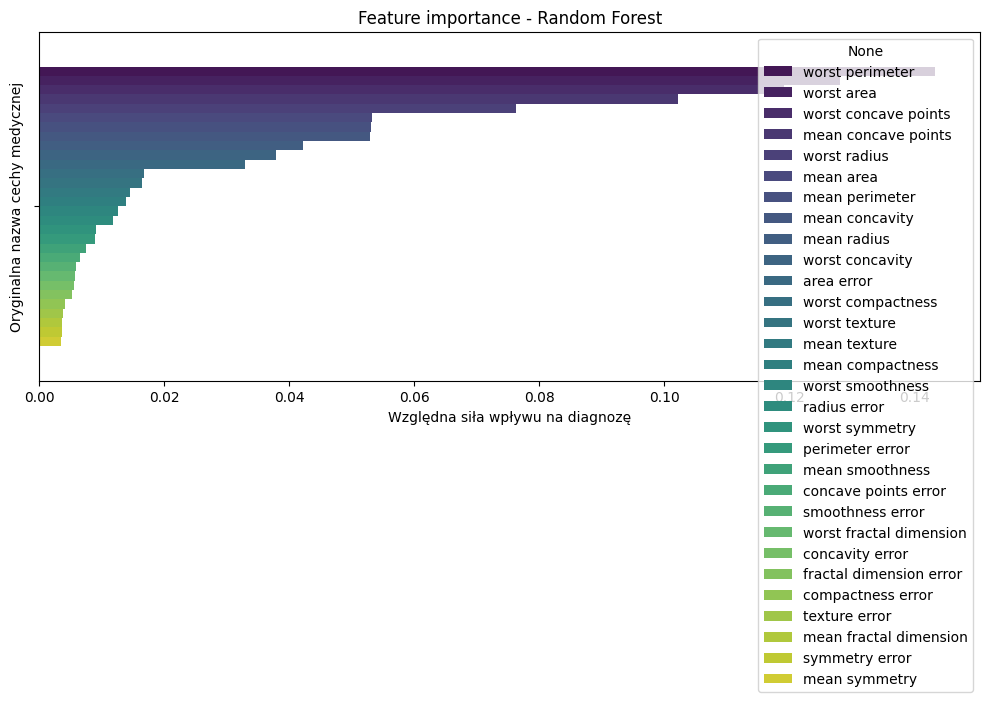

In [51]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# 1. Załadowanie zbioru
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# 2. Inicjalizacja i trening potężnego estymatora - Lasu Losowego
# Ustawiamy n_jobs=-1, by trenować wszystkie drzewa równolegle (szybki start)
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
print("Trwa trenowanie Lasu Losowego...")
rf.fit(X, y)

# 3. Wyodrębnienie Feature Importances (Wag Cech) z wytrenowanego modelu wewnętrznego
# Algorytm w trakcie budowy rozgałęzień samodzielnie zapisał, z których wymiarów czerpał najwyższy zysk z optymalizacji podziału bazy ustalonego warunku.
importances = pd.Series(rf.feature_importances_, index=X.columns)

feature_importance = importances.sort_values(ascending=False)

print("-" * 50)
print("Top 5 cech medycznych według matematyki Random Forest:")
print(feature_importance.head(5))

# 4. Dodatkowa wizualizacja użyteczna na wykładach
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, hue=feature_importance.index, palette="viridis")
plt.title("Feature importance - Random Forest")
plt.xlabel("Względna siła wpływu na diagnozę")
plt.ylabel("Oryginalna nazwa cechy medycznej")
plt.tight_layout()
plt.show()

**Wnioski omawiające algorytm:**

Algorytmy iteracyjnie oparte na setkach drzew decyzyjnych to kopalnia rzetelnej wiedzy analitycznej. Gdy model decydował, względem jakiej warunkowości podzielić diagnozę nowotworu na dwie mniejsze podgrupy dla nowego węzła drzewa, musiał ocenić na podstawie GINI, która podgrupa odrzuci więcej błędu matematycznego. 

**GINI** - **Gini Impurity/Gini Index** w algorytmie Random Forest to miara zanieczyszczenia lub nieczystości węzła w drzewie decyzyjnym. Określa on, jak dobrze dany podział w drzewie rozdziela dane na poszczególne klasy.

Proces ten zsumowany z 200 iteracji Random Forest ukazuje nam czystą, gotową estymację wagi poszczególnej cechy. Wykres w seaborn wyraźnie ukazuje wręcz logarytmiczny spadek przydatności kolejnych cech. Pokazuje to naocznie powód nauki selekcji – wycięcie rzadszych cech da nam ogromną oszczędność pamięci i przyspieszenie uczenia algorytmów optymalizacyjnych przy całkowicie akceptowalnej (np. $2-5\%$) utracie dokładności, co w chmurze i realnym środowisku oszczędzi bardzo dużo pieniędzy firmie.

## 3. Redukcja wymiarowości

**Czym jest redukcja wymiarowości?**
  
  Jest to proces kompresji danych polegający na przekształceniu zbioru o dużej liczbie wymiarów w zbiór o znacznie mniejszej liczbie wymiarów, przy jednoczesnym zachowaniu jak największej ilości "istotnych informacji" (z reguły mierzonej jako wariancja/rozrzut punktów danych w przestrzeni wielowymiarowej).
  
**Redukcja wymiarowości a selekcja cech – kluczowa różnica:**
  * **Selekcja:**
    * Wybiera podzbiór fizycznie istniejących wymiarów, a resztę usuwa (interpretacja danych pozostaje nienaruszona, np. "Wiek" nadal oznacza Wiek pacjenta).
  * **Redukcja:**
    * Tworzy zbiór matematycznie **nowych** wymiarów, będących najczęściej sztuczną kombinacją liniową oryginalnych wejść. Otwiera to drogę do wizualizacji ogromnej struktury wielowymiarowych obiektów na płaszczyznach 2D lub 3D, jednak tracimy tu bezpośrednią interpretację wejściową (np. nowopowstały "Wymiar 1" składa się po trochu w 20% z wieku, 70% z dochodu i 10% wykształcenia).

**Analiza Głównych Składowych (PCA - Principal Component Analysis):**
  * Wyszukuje nowe osie współrzędnych **(Główne Składowe / Principal Components)** wzdłuż kierunków, w których dane wykazują największy rozrzut na geometrycznej siatce (największą wariancję). Następnie rzuca (projekcja) strukturę przestrzenną naszych danych na te nowo powstałe, sztuczne osie.
  * Każda kolejna składowa PCA jest w przestrzeni prostopadła (ortogonalna) do pozostałych – gwarantuje to liniową niezależność nowowygenerowanych cech.
  * **Ważne:**
    * Z racji silnego polegania na całkowitej wariancji, PCA **matematycznie wymaga** ustandaryzowania macierzy (krok `StandardScaler`) przed wymnożeniem estymatora!

**Nieliniowe alternatywy:**
  * Algorytm PCA jest metodą liniową i globalną. Do poszukiwania skomplikowanych nieliniowych i lokalnych relacji służą t-SNE czy algorytm UMAP (często stosowane rygorystycznie do samej ostatecznej prezentacji wizualizacji badanych architektur dla klienta).

### Algorytm PCA

**Intuicja Geometryczna: Gra Cieni**

Wyobraź sobie, że trzymasz w ręku trójwymiarowy model samolotu z klocków Lego i chcesz zrobić mu zdjęcie dwuwymiarowe, z którego Twój znajomy będzie w stanie rozpoznać, że to samolot.

Jeśli zrobisz zdjęcie idealnie od przodu, zobaczy tylko krzyżyk (skrzydła i kadłub).

Jeśli zrobisz zdjęcie z góry lub z boku, zobaczy kształt samolotu w pełnej krasie.

PCA to algorytm, który matematycznie szuka najlepszego "kąta zrobienia zdjęcia". **Robi to, szukając kierunku, w którym punkty danych są najbardziej rozstrzelone (mają największą wariancję)**. 

Dlaczego? 

Ponieważ tam, gdzie jest największa wariancja, tam znajduje się najwięcej informacji o strukturze danych.

#### PCA Krok po Kroku

Załóżmy, że mamy zbiór danych $X$ o wymiarach $n \times d$ ($n$ próbek, $d$ cech). Naszym celem jest zredukowanie liczby cech do $k$ (gdzie $k < d$).

##### Krok 1: Standaryzacja / Centrowanie danych
Aby PCA działało poprawnie, wszystkie cechy muszą być w tej samej skali i wyśrodkowane wokół zera. Obliczamy średnią $\mu$ dla każdej kolumny i odejmujemy ją od naszych danych:

$$X_{centered} = X - \mu$$

*Opcjonalnie (ale bardzo często) dzielimy też przez odchylenie standardowe $\sigma$, jeśli cechy były w zupełnie różnych jednostkach (np. kilometry i milisekundy).*

##### Krok 2: Obliczenie Macierzy Kowariancji
Chcemy sprawdzić, jak nasze cechy są ze sobą skorelowane (jak "zmieniają się" względem siebie). Obliczamy macierz kowariancji $C$ o wymiarach $d \times d$:

$$C = \frac{1}{n-1} X_{centered}^T X_{centered}$$

Gdzie $X^T$ to macierz transponowana. Każdy element tej macierzy mówi nam, czy dwie cechy rosną razem, maleją razem, czy są od siebie niezależne.

##### Krok 3: Wektory i Wartości Własne (Eigendecomposition)
To serce PCA. Szukamy takich wektorów w przestrzeni (kierunków), które po przekształceniu przez naszą macierz kowariancji $C$ nie zmieniają swojego kierunku, a jedynie długość.

Rozwiązujemy równanie:

$$C \mathbf{v} = \lambda \mathbf{v}$$

* **Wektory własne ($\mathbf{v}$):** To nasze nowe osie układu współrzędnych – nazywamy je **Głównymi Składowymi** (Principal Components). Mówią o kierunku największej wariancji.
* **Wartości własne ($\lambda$):** To skalary przypisane do wektorów. Mówią nam, **ile wariancji (informacji)** zachowuje dany wektor.

##### Krok 4: Wybór Składowych (Redukcja)
Sortujemy nasze wektory własne malejąco według ich wartości własnych $\lambda$.
Jeśli chcemy zredukować wymiarowość z $d$ na $k$, po prostu bierzemy $k$ wektorów z najwyższą wartością $\lambda$. Tworzą one macierz projekcji $W$ (o wymiarach $d \times k$).

##### Krok 5: Rzutowanie (Projekcja) do nowej przestrzeni
Teraz bierzemy nasze wyśrodkowane dane i rzutujemy je na nowe, wybrane osie poprzez mnożenie macierzy:

$$X_{pca} = X_{centered} W$$

Wynikiem jest nowa macierz $X_{pca}$ o wymiarach $n \times k$. Skompresowaliśmy dane!

------------------------------ oryginalna ramka ------------------------------




,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


------------------------------ ramka po kompresji PCA ------------------------------




,Principal Component 1,Principal Component 2,Target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0
3,-2.299384,-0.597395,0
4,-2.389842,0.646835,0
5,-2.075631,1.489178,0
6,-2.444029,0.047644,0
7,-2.232847,0.223148,0
8,-2.334640,-1.115328,0
9,-2.184328,-0.469014,0


------------------------------ macierz kowariancji dla oryginalnej ramki danych ------------------------------




,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),0.685694,-0.042434,1.274315,0.516271
sepal width (cm),-0.042434,0.189979,-0.329656,-0.121639
petal length (cm),1.274315,-0.329656,3.116278,1.295609
petal width (cm),0.516271,-0.121639,1.295609,0.581006


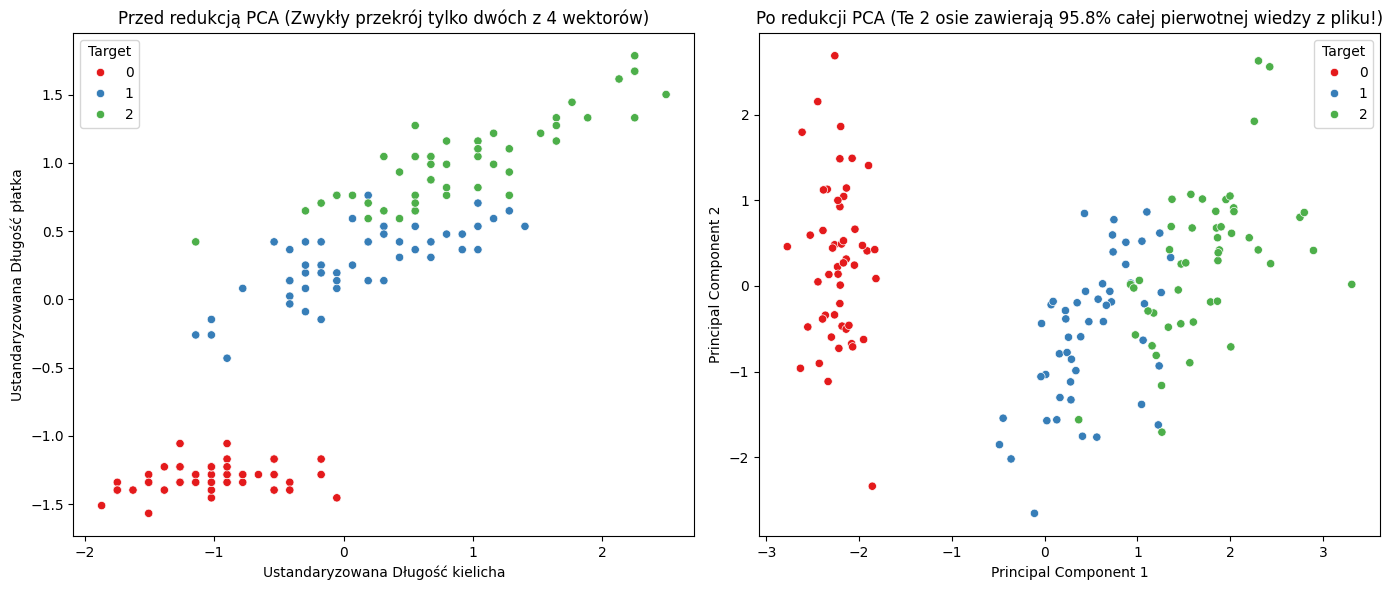

In [20]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Załadowanie 4-wymiarowego zbioru
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# 2. STANDARYZACJA DANYCH - Krok absolutnie krytyczny dla PCA!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Model PCA - żądamy redukcji z wbudowanych oryginalnie 4D na skompresowane 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Tworzenie pomocniczych, ustandaryzowanych ramek danych "przed i po" do narysowania czytelnych wykresów z wynikiem targetu
df_original = pd.DataFrame(X_scaled, columns=iris.feature_names)
df_original['Target'] = y
print(f"{'-' * 30} oryginalna ramka {'-' * 30}", end='\n\n\n')
df_iris = pd.DataFrame(X, columns=iris.feature_names)
df_iris['Target'] = y
display(df_iris.head(10))

df_pca = pd.DataFrame(X_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_pca['Target'] = y
print(f"{'-' * 30} ramka po kompresji PCA {'-' * 30}", end='\n\n\n')
display(df_pca.head(10))

print(f"{'-' * 30} macierz kowariancji dla oryginalnej ramki danych {'-' * 30}", end='\n\n\n')
display(df_iris.iloc[:, :-1].cov())

# Sprawdzenie wskaźnika Wariancji Wyjaśnionej (Explained Variance Ratio)
# Pokazuje precyzyjnie matematycznie, ile % utraciliśmy poprzez drastyczną kompresję z wyjściowych 4 wymiarów do 2 wymiarów.
explained_variance = sum(pca.explained_variance_ratio_) * 100

# 4. Finalna, wygenerowana siatka wizualizacji matplotlib: Przestrzeń wejściowa kontra zredukowana przestrzeń PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# A) Wykres przed redukcją: Pokazanie dwóch przypadkowych, rzuconych bez mapowania układu współrzędnych fizycznych wymiarów (z 4 dostępnych).
sns.scatterplot(
    x='sepal length (cm)', y='petal length (cm)', 
    hue='Target', palette='Set1', data=df_original, ax=axes[0]
)
axes[0].set_title('Przed redukcją PCA (Zwykły przekrój tylko dwóch z 4 wektorów)')
axes[0].set_xlabel('Ustandaryzowana Długość kielicha')
axes[0].set_ylabel('Ustandaryzowana Długość płatka')

# B) Wykres po redukcji PCA (Skondensowano równomiernie cały 4-wymiarowy zbiór z dbałością do zaledwie dwóch potężnych wektorów!)
sns.scatterplot(
    x='Principal Component 1', y='Principal Component 2', 
    hue='Target', palette='Set1', data=df_pca, ax=axes[1]
)
axes[1].set_title(f'Po redukcji PCA (Te 2 osie zawierają {explained_variance:.1f}% całej pierwotnej wiedzy z pliku!)')

plt.tight_layout()
plt.show()

In [ ]:
!pip install ipywidgets
# oraz dodatkowo należy doinstalować obługę tego rozszerzenia w jupyter na podstawie porad z https://stackoverflow.com/questions/36351109/ipython-notebook-ipywidgets-does-not-show

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Checkbox

def plot_pca(korelacja=0.7, pokaz_rzutowanie=False):
    # 1. Generowanie syntetycznych danych 2D
    np.random.seed(42) # Dla powtarzalności wyników
    mean = [0, 0]
    # Tworzymy macierz kowariancji na podstawie wybranej korelacji
    cov = [[1.0, korelacja], [korelacja, 1.0]] 
    X = np.random.multivariate_normal(mean, cov, 150)
    
    # 2. Obliczenia PCA
    # Obliczamy macierz kowariancji (transponujemy X, bo np.cov oczekuje cech w wierszach)
    C = np.cov(X.T)
    
    # Obliczamy wartości i wektory własne
    eigvals, eigvecs = np.linalg.eigh(C)
    
    # Sortujemy wektory malejąco według wartości własnych (aby PC1 było pierwsze)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    
    # Wyodrębniamy PC1 i PC2
    v1 = eigvecs[:, 0]
    v2 = eigvecs[:, 1]

    # Obliczanie procentowej wyjaśnionej wariancji
    explained_variance_ratio = eigvals / np.sum(eigvals)

    # Wyświetlenie wyników
    for i, ratio in enumerate(explained_variance_ratio):
        print(f"PC{i+1} wyjaśnia: {ratio:.2%} wariancji")
    
    # 3. Konfiguracja wykresu
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_aspect('equal') # WAŻNE: zachowuje kąty proste, by PC1 i PC2 były wizualnie prostopadłe
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    
    # Rysowanie punktów oryginalnych
    ax.scatter(X[:, 0], X[:, 1], alpha=0.5, edgecolor='k', label='Oryginalne dane')
    
    # Rysowanie wektorów (Głównych Składowych)
    # Skalujemy długość wektora proporcjonalnie do odchylenia standardowego (pierwiastek z wartości własnej)
    scale1 = np.sqrt(eigvals[0]) * 2
    scale2 = np.sqrt(eigvals[1]) * 2
    
    ax.annotate('', xy=v1*scale1, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='red', lw=3))
    ax.annotate('', xy=v2*scale2, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='blue', lw=3))
    
    ax.text(v1[0]*scale1 * 1.1, v1[1]*scale1 * 1.1, 'PC1', color='red', fontsize=12, fontweight='bold')
    ax.text(v2[0]*scale2 * 1.1, v2[1]*scale2 * 1.1, 'PC2', color='blue', fontsize=12, fontweight='bold')
    
    # 4. Opcjonalne rzutowanie punktów na oś PC1
    if pokaz_rzutowanie:
        # Wzór na rzutowanie punktów na wektor v1: X_proj = (X dot v1) * v1
        X_proj = np.outer(np.dot(X, v1), v1)
        
        # Rysowanie przerywanych linii łączących oryginalny punkt z jego rzutem
        for i in range(len(X)):
            ax.plot([X[i, 0], X_proj[i, 0]], [X[i, 1], X_proj[i, 1]], 'gray', linestyle=':', alpha=0.4)
            
        # Rysowanie zrzutowanych punktów
        ax.scatter(X_proj[:, 0], X_proj[:, 1], color='red', s=25, zorder=5, label='Rzut na PC1 (1D)')
        
    ax.legend(loc='upper left')
    ax.set_title(f'Wizualizacja PCA (Korelacja w danych: {korelacja:.2f})')
    plt.show()

# 5. Podpięcie interfejsu ipywidgets
interact(
    plot_pca, 
    korelacja=FloatSlider(value=0.7, min=-0.95, max=0.95, step=0.05, description='Korelacja:'),
    pokaz_rzutowanie=Checkbox(value=False, description='Pokaż rzutowanie (PC1)')
);

interactive(children=(FloatSlider(value=0.7, description='Korelacja:', max=0.95, min=-0.95, step=0.05), Checkb…

### Na co należy uważać stosując PCA?

* **Modele nieliniowe:** PCA zakłada, że zależności w danych są liniowe. Jeśli Twoje dane przypominają np. kształt "szwajcarskiego roladki" (swiss roll), standardowe PCA zawiedzie (wtedy stosuje się tSNE, UMAP lub Kernel PCA).
* **Utrata interpretowalności:** Nowe kolumny PC1, PC2 nie nazywają się już "Wiek" czy "Zarobki". Są matematycznymi miksami wielu oryginalnych cech, co utrudnia ich biznesowe wytłumaczenie.